In [1]:
import numpy as np

import matplotlib.pyplot as plt
import corner 

import jax
import jax.numpy as jnp
from jesterTOV.inference.flows import ConditionalFlow

In [78]:
posterior_gw = np.load("../../eos_inference/wide_ETT/gw_posteriors/source_1/posterior_mm.npz")
cflow = ConditionalFlow.from_directory("./gw_posteriors/source_1/cnf")

In [79]:
lambdas_arr = cflow.sample(jax.random.key(42), (1,), y=jnp.array([posterior_gw["mass_1"][:2000], posterior_gw["mass_2"][:2000]]).T)

In [80]:
data = np.stack((lambdas_arr[0][:,0], lambdas_arr[0][:,1], posterior_gw["mass_1"][:2000], posterior_gw["mass_2"][:2000]), axis=1)

data_posterior = np.stack((posterior_gw["lambda_1"][:2000], posterior_gw["lambda_2"][:2000], posterior_gw["mass_1"][:2000], posterior_gw["mass_2"][:2000]), axis=1)

In [82]:
data_posterior[:, 2]

array([1.90260114, 2.10480033, 2.03627671, ..., 2.16702369, 2.11536009,
       2.07015479], shape=(2000,))

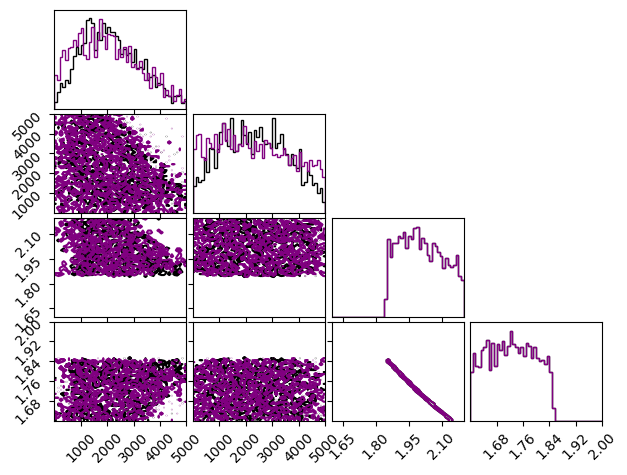

In [84]:
range = [(0, 5000), (0, 5000), (1.6, 2.2), (1.6, 2)]


fig, ax = plt.subplots(4, 4)
corner.corner(data, bins=50, 
              plot_density=False, 
              plot_datapoints=False, 
              levels=[0.68, 0.95],
              range=range,
              fig=fig,)

corner.corner(data_posterior, bins=50, 
              plot_density=False, 
              plot_datapoints=False, 
              levels=[0.68, 0.95],
              range=range,
              color="purple",
              fig=fig)
plt.show()